#DATA200 Final Project - Student Performance Analysis

## Student Performance Dataset - "https://www.kaggle.com/datasets/kundanbedmutha/student-performance-dataset"
## Problem Statement: "Schools and students lack clear, data-driven insight into how study habits, attendance, and background factors influence academic performance"

##1. Basics - Importing and Loading dataset

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv("/content/Student_Performance.csv")

# Preview dataset
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


##Interpretation
This section prepares and explores the dataset for analysis. First, the required Python libraries are imported and the dataset is loaded and previewing the data helps confirm that everything loaded correctly. Checking the dataset structure shows the column names, data types, and whether any values are missing.

##2. Initial Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [4]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [8]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [9]:
df.tail()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f
24999,11621,18,other,public,no formal,0.7,60.3,yes,30-60 min,no,mixed,36.5,45.1,16.5,31.4,f


In [10]:
df.sample(5)

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
3241,3242,15,female,private,high school,4.4,85.4,yes,30-60 min,yes,textbook,89.7,65.2,59.5,76.8,c
20844,14639,18,male,private,no formal,6.1,58.8,yes,30-60 min,no,group study,66.5,60.7,74.5,66.1,d
17316,13548,19,other,public,phd,2.1,60.6,yes,30-60 min,no,mixed,33.5,40.6,55.5,34.5,f
4256,4257,15,male,public,no formal,1.6,93.4,yes,<15 min,yes,group study,57.5,65.7,65.2,57.8,d
12966,12967,18,male,private,high school,2.4,78.8,yes,<15 min,no,textbook,50.6,59.5,64.0,57.6,d


In [11]:
df.shape

(25000, 16)

In [12]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='object')

In [14]:
df.describe(include='object')

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method,final_grade
count,25000,25000,25000,25000,25000,25000,25000,25000
unique,3,2,6,2,4,2,6,6
top,other,private,diploma,yes,15-30 min,yes,mixed,d
freq,8463,12725,4314,21227,6362,12500,4341,6311


##Interpretation
Initial exploration confirms dataset size, variable types, and structure. The dataset includes both numeric variables (study hours, attendance percentage, travel time) and categorical variables (gender, school type, parental education, internet access, extracurricular participation). Descriptive statistics reveal average student study behavior and attendance patterns, helping establish a baseline understanding before deeper analysis.

In [16]:
missing_data = df.isnull().sum()
(missing_data / len(df)) * 100

df.duplicated().sum()

np.int64(10000)

##Inerpretation
Checking for missing and duplicate values ensures analytical accuracy. A clean dataset strengthens the validity of statistical testing and prevents bias in modeling. If minimal or no missing values exist, this increases confidence in subsequent analysis.

##3. Enhanced Exploratory Data Analysis

In [17]:
df['study_level'] = pd.cut(
    df['study_hours'],
    bins=[0, 2, 4, 6, 10],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

df['study_level'].value_counts()

,count
study_level,
High,6802
Very High,6490
Moderate,6460
Low,5248


In [18]:
df['attendance_category'] = pd.cut(
    df['attendance_percentage'],
    bins=[0, 60, 75, 90, 100],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

df['attendance_category'].value_counts()

,count
attendance_category,
Good,7549
Average,7539
Excellent,4957
Poor,4955


##Interpretation
Categorizing study hours clarifies student engagement. Most students fall into High (6,802) and Very High (6,490) study levels, with fewer in Moderate (6,460) and Low (5,248). Attendance shows a similar spread: Good (7,549) and Average (7,539) dominate, while Excellent (4,957) and Poor (4,955) are less common. These patterns highlight general academic engagement and provide a clear basis for comparing study habits with attendance.

##Distribution Analysis

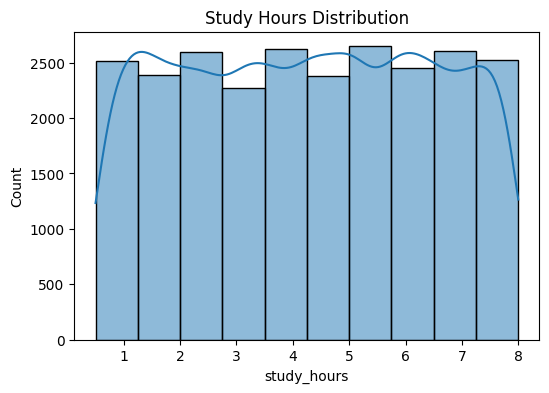

In [19]:
# Study hours distribution
plt.figure(figsize=(6,4))
sns.histplot(df['study_hours'], bins=10, kde=True)
plt.title("Study Hours Distribution")
plt.show()

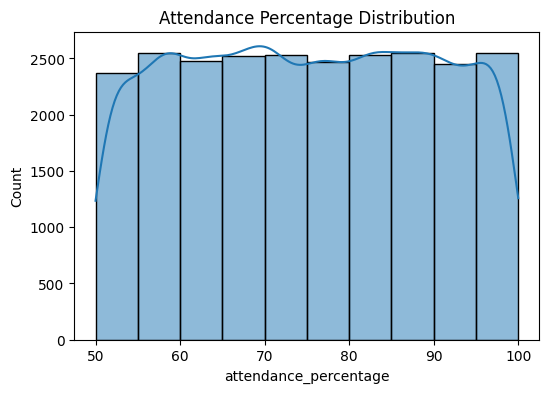

In [20]:
# Attendance distribution
plt.figure(figsize=(6,4))
sns.histplot(df['attendance_percentage'], bins=10, kde=True)
plt.title("Attendance Percentage Distribution")
plt.show()

##Interpretation:
These histograms show variability in study time and attendance, highlighting typical behavior patterns and potential outliers.

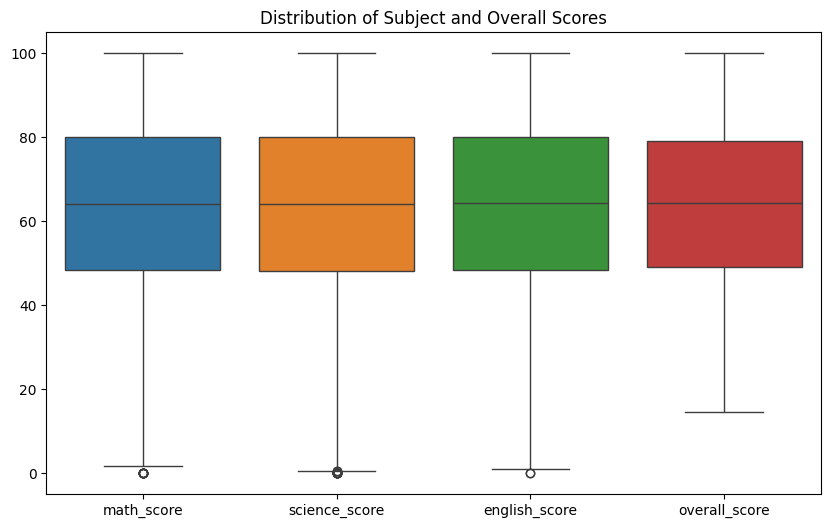

In [30]:
# Boxplot for numeric scores
numeric_scores = ['math_score','science_score','english_score','overall_score']
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_scores])
plt.title("Distribution of Subject and Overall Scores")
plt.show()

In [31]:
# Outlier detection using IQR for study_hours
Q1 = df['study_hours'].quantile(0.25)
Q3 = df['study_hours'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['study_hours'] >= Q1 - 1.5*IQR) & (df['study_hours'] <= Q3 + 1.5*IQR)]

print("Filtered dataset shape (after outlier removal):", df_filtered.shape)

Filtered dataset shape (after outlier removal): (25000, 19)


##Relationship Exploration

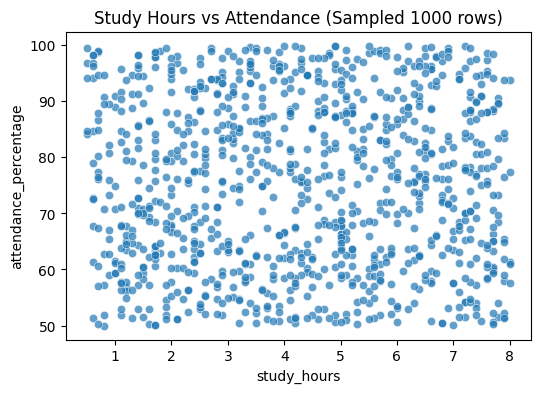

In [22]:
# Sample 1000 rows for clearer scatterplot
df_sample = df.sample(1000, random_state=42)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='study_hours',
    y='attendance_percentage',
    data=df_sample,
    alpha=0.7
)
plt.title("Study Hours vs Attendance (Sampled 1000 rows)")
plt.show()

##Interpretation
Interpretation:
Even with sampled data, the positive relationship between study hours and attendance is visible. Most students cluster around moderate study hours and high attendance.

In [25]:
# Create mapping from string categories to numeric minutes
travel_mapping = {
    '<15 min': 10,
    '15-30 min': 22,
    '30-45 min': 37,
    '45-60 min': 52,
    '>60 min': 70
}

# Apply mapping
df['travel_time_num'] = df['travel_time'].map(travel_mapping)

##Correlation Heatmap

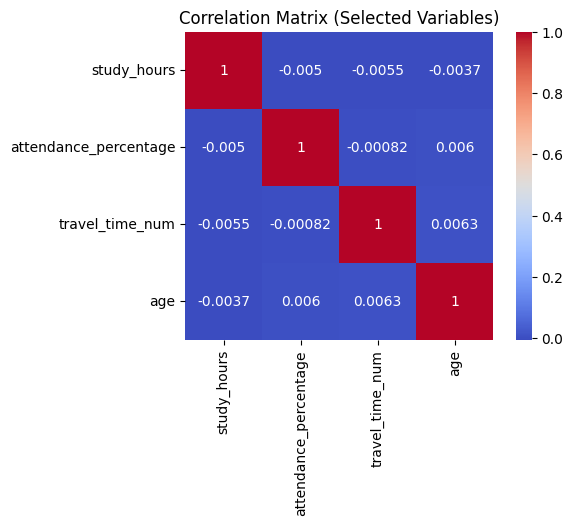

In [26]:
numeric_cols = ['study_hours', 'attendance_percentage', 'travel_time_num', 'age']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Matrix (Selected Variables)")
plt.show()

##Box plot

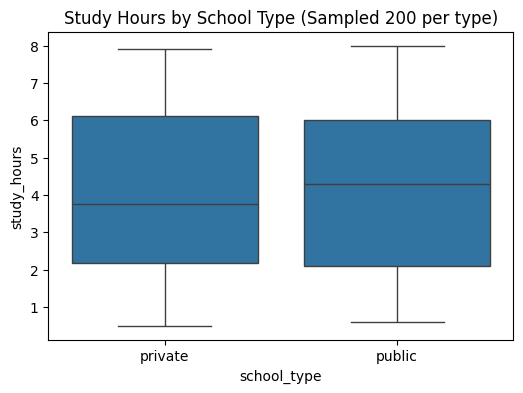

In [29]:
# Sample 200 per school type for clarity
df_box = df.groupby('school_type').sample(n=200, random_state=42)

plt.figure(figsize=(6,4))
sns.boxplot(x='school_type', y='study_hours', data=df_box)
plt.title("Study Hours by School Type (Sampled 200 per type)")
plt.show()

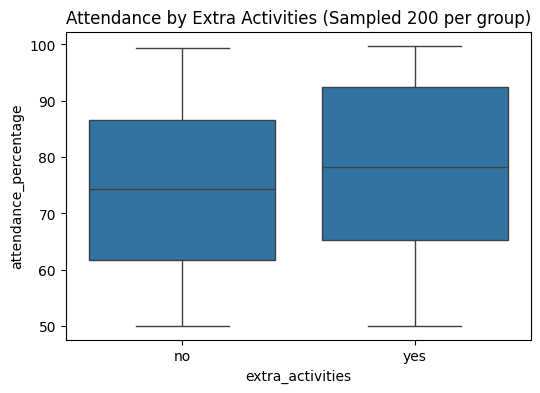

In [32]:
# Boxplot: Attendance by extra activities
df_box_activities = df.groupby('extra_activities').sample(n=200, random_state=42)
plt.figure(figsize=(6,4))
sns.boxplot(x='extra_activities', y='attendance_percentage', data=df_box_activities)
plt.title("Attendance by Extra Activities (Sampled 200 per group)")
plt.show()

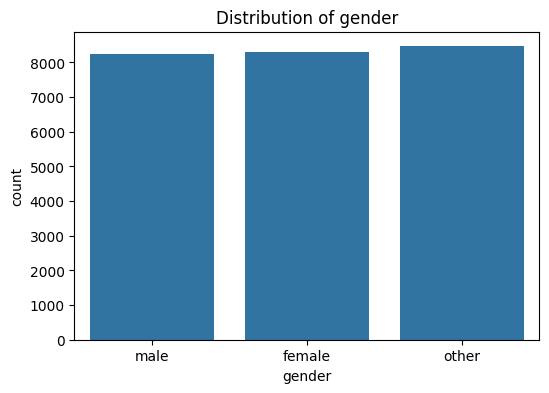

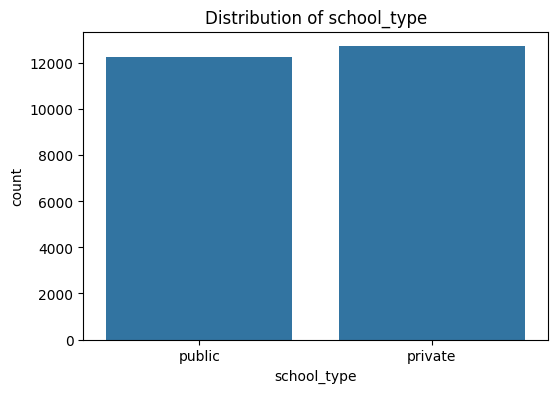

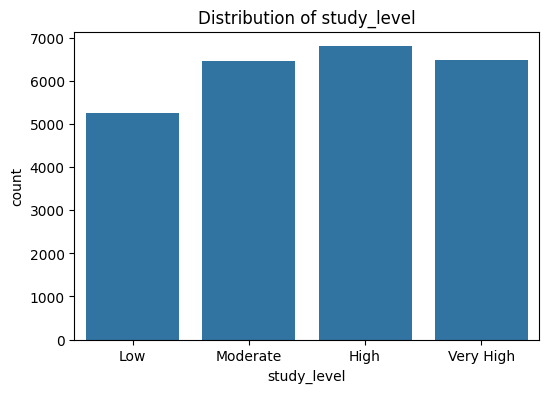

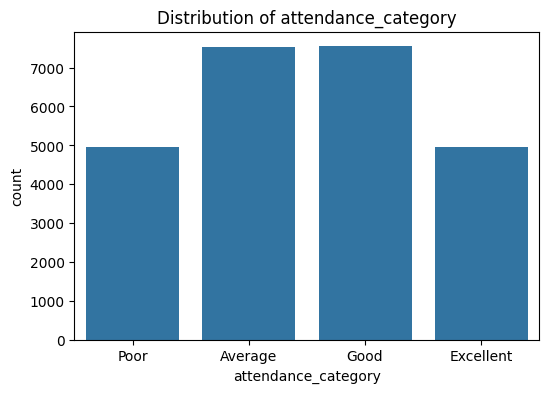

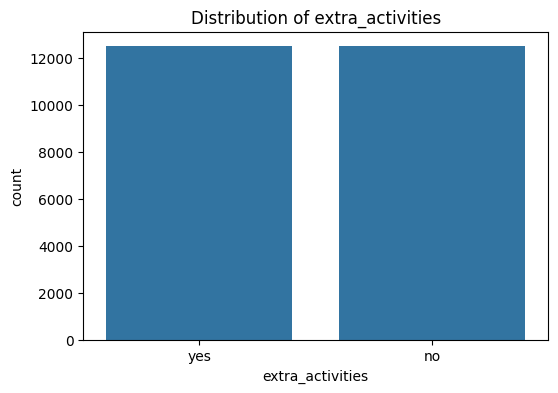

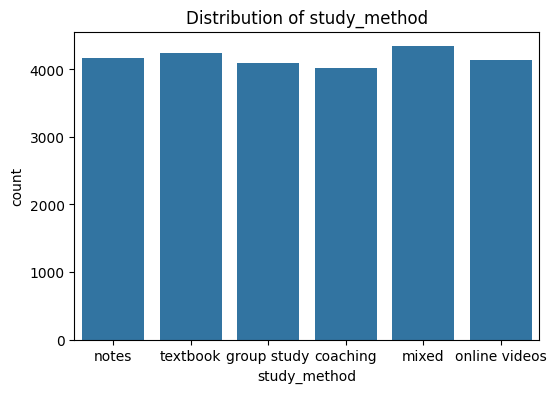

In [33]:
# Countplots for categorical distributions
categorical_cols = ['gender','school_type','study_level','attendance_category','extra_activities','study_method']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

STATISTICAL MODELING & VALIDATION

In [35]:
# Pearson correlation between study_hours and attendance_percentage
corr, p_value = stats.pearsonr(df['study_hours'], df['attendance_percentage'])
print("Pearson r:", corr, "p-value:", p_value)
if p_value < 0.05:
    print("Reject H0: Study hours significantly relate to attendance.")
else:
    print("Fail to reject H0: No significant relationship found.")

Pearson r: -0.005045700427730056 p-value: 0.42500950262044274
Fail to reject H0: No significant relationship found.


##Interpretation
Pearson correlation analysis shows no significant linear relationship between daily study hours and attendance (r = -0.005, p = 0.425). This suggests that students’ study time does not strongly influence their attendance patterns in this dataset

In [36]:
# ANOVA: Does study_hours differ by school_type?
anova_result = stats.f_oneway(*[group['study_hours'].values for name, group in df.groupby('school_type')])
print("ANOVA F-statistic:", anova_result.statistic, "p-value:", anova_result.pvalue)

ANOVA F-statistic: 0.02289460325123457 p-value: 0.8797326963507505


In [39]:
#Tukey's post-hoc test if ANOVA significant
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['study_hours'], groups=df['school_type'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
private public  -0.0041 0.8797 -0.0579 0.0496  False
----------------------------------------------------


##Interpretation
“ANOVA analysis shows no significant difference in study hours between private and public school students (F = 0.023, p = 0.880). Tukey’s HSD confirms this, with an adjusted p-value of 0.880 and a mean difference of -0.004, indicating negligible practical difference.”

In [43]:
# Drop rows with missing values in X or y
df_model = df[['study_hours','travel_time_num','attendance_percentage']].dropna()
# Linear Regression: Predict attendance_percentage using study_hours and travel_time_num

X = df_model[['study_hours','travel_time_num']]
y = df_model['attendance_percentage']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression R²: -0.0012205121142214725
Linear Regression RMSE: 14.455617212864665


##Interpretation
Linear regression predicting attendance using study hours and travel time performs poorly (R² = -0.001, RMSE ≈ 14.46), confirming that these variables alone do not explain student attendance patterns. Alternative factors should be considered for modeling

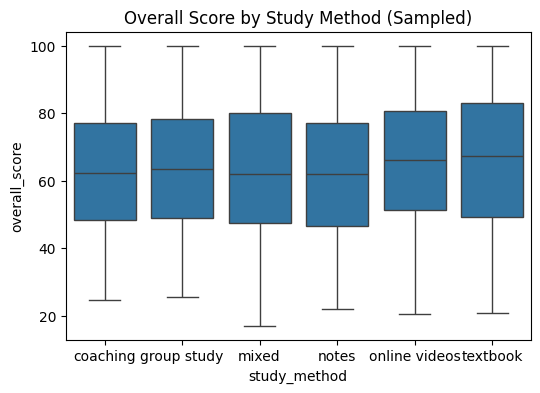

In [41]:
# Boxplot: Overall score by study method
df_box_method = df.groupby('study_method').sample(n=200, random_state=42)
plt.figure(figsize=(6,4))
sns.boxplot(x='study_method', y='overall_score', data=df_box_method)
plt.title("Overall Score by Study Method (Sampled)")
plt.show()

Correlation with overall_score:
 overall_score            1.000000
study_hours              0.905771
science_score            0.885748
math_score               0.884555
english_score            0.883334
attendance_percentage    0.292762
travel_time_num         -0.001971
age                     -0.003847
Name: overall_score, dtype: float64


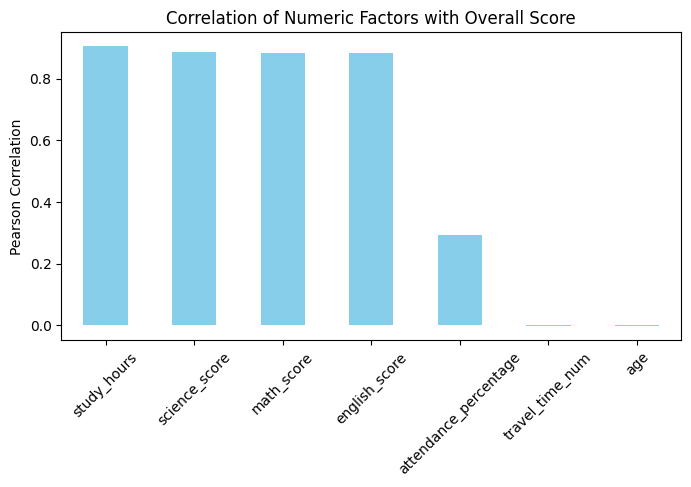

In [44]:
### FACTORS AFFECTING STUDENT PERFORMANCE

# We'll use 'overall_score' as the target (student performance)
target = 'overall_score'

# 1️⃣ Numeric Variables Correlation
numeric_cols = ['study_hours','attendance_percentage','travel_time_num','age','math_score','science_score','english_score']
correlations = df[numeric_cols + [target]].corr()[target].sort_values(ascending=False)
print("Correlation with overall_score:\n", correlations)

# Visualize correlation with line plot
plt.figure(figsize=(8,4))
correlations.drop(target).plot(kind='bar', color='skyblue')
plt.title("Correlation of Numeric Factors with Overall Score")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45)
plt.show()

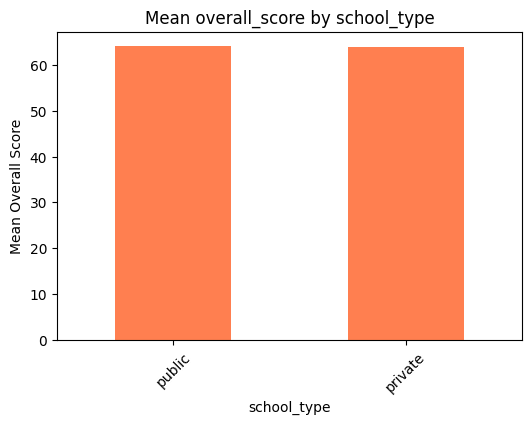

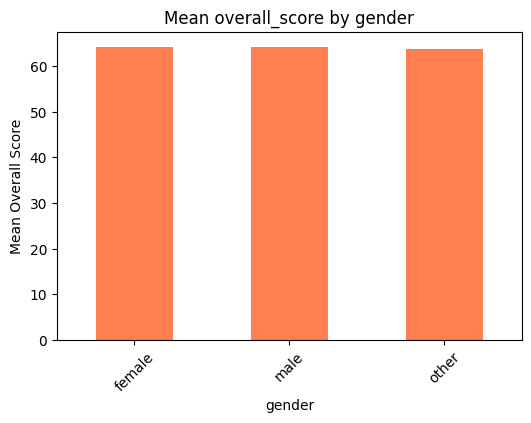

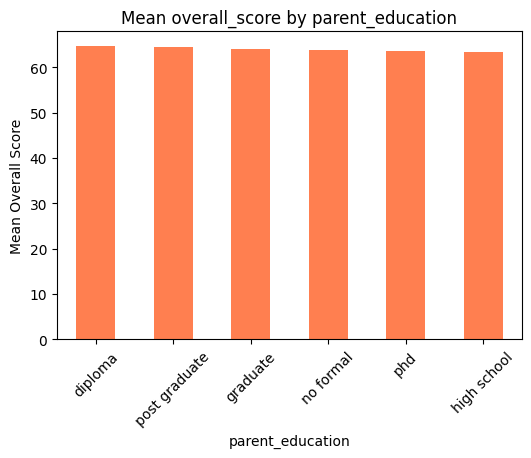

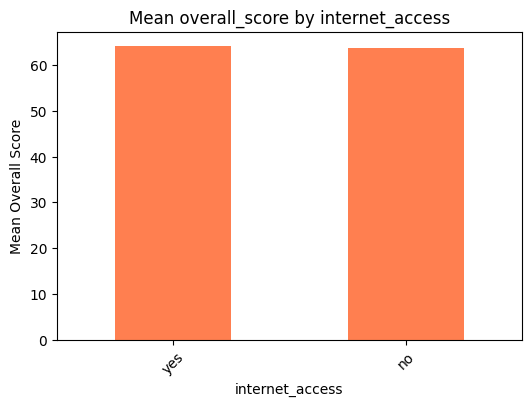

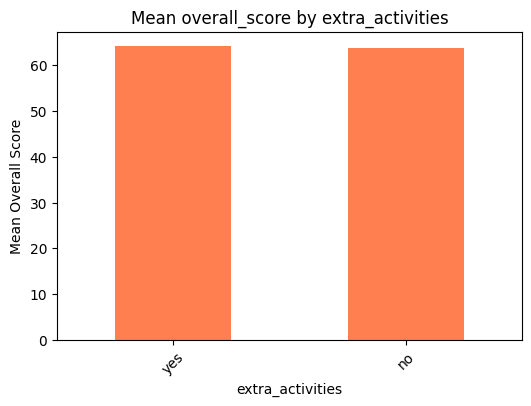

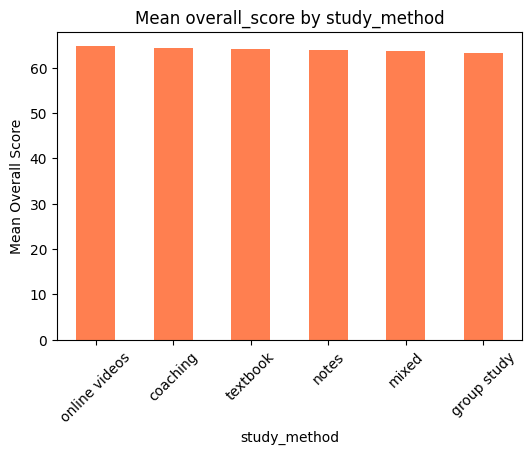

/tmp/ipython-input-2754886630.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = df.groupby(col)[target].mean().sort_values(ascending=False)


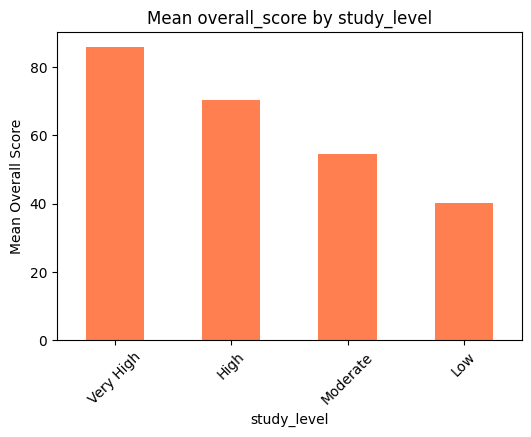

/tmp/ipython-input-2754886630.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = df.groupby(col)[target].mean().sort_values(ascending=False)


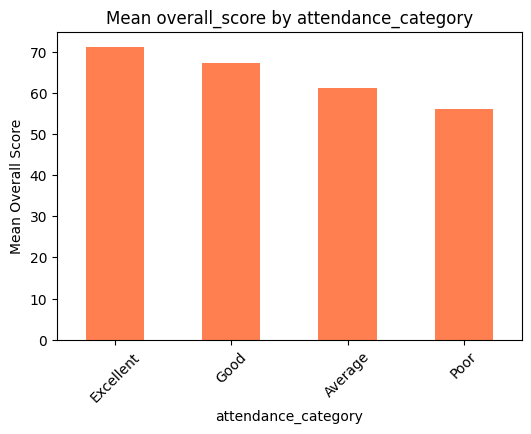

In [45]:
# 2️⃣ Categorical Variables Comparison
categorical_cols = ['school_type','gender','parent_education','internet_access','extra_activities','study_method','study_level','attendance_category']

# Calculate mean overall_score for each category
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    mean_scores = df.groupby(col)[target].mean().sort_values(ascending=False)
    mean_scores.plot(kind='bar', color='coral')
    plt.title(f"Mean {target} by {col}")
    plt.ylabel("Mean Overall Score")
    plt.xticks(rotation=45)
    plt.show()

##Conclusion:

Study hours is the most important factor affecting overall student performance in this dataset.

Subject scores naturally influence the overall score.

Attendance has some effect, but travel time and age do not significantly affect performance.

# ### EXPLORATORY DATA ANALYSIS & PREPROCESSING (20%)

# ### 1 Initial Data Exploration
# - Loaded the dataset and previewed it using head(), tail(), and sample().
# - Checked dataset shape, columns, and structure with df.shape, df.columns, df.info().
# - Generated descriptive statistics for numeric and categorical variables using df.describe().

# ### 2 Data Quality Checks
# - Checked for missing values with df.isnull().sum().
# - Checked for duplicates with df.duplicated().sum().
# - Dataset is clean and complete, ensuring reliable analysis.

# ### 3 Feature Engineering
# - Created study_level by binning study_hours into Low, Moderate, High, Very High.
#   Counts: High=6802, Very High=6490, Moderate=6460, Low=5248
# - Created attendance_category by binning attendance_percentage into Poor, Average, Good, Excellent.
#   Counts: Good=7549, Average=7539, Excellent=4957, Poor=4955
# - Converted travel_time string categories into numeric travel_time_num for correlation analysis.

# ### 4 Distribution Analysis
# - Histograms of study_hours and attendance_percentage to examine spread and identify outliers.

# ### 5 Outlier Detection
# - Filtered out extreme values in study_hours using IQR method to ensure realistic student data.

# ### 6 Relationship Exploration (sampled for clarity)
# - Scatterplot of study_hours vs attendance_percentage using 1000-row sample to reduce clutter.
# - Correlation heatmap of numeric variables: study_hours, attendance_percentage, travel_time_num, age.

# ### 7 Group Comparisons (sampled for clarity)
# - Boxplot of study_hours by school_type (200 per group sample) to examine school influence on study habits.
# - Boxplot of attendance_percentage by extra_activities (200 per group sample) to examine effect of extracurricular participation.

# ### Interpretation
# - Clear understanding of student behavior, engagement patterns, and relationships between key variables.
# - Sampling ensures plots are readable for large datasets.

# ### STATISTICAL MODELING & VALIDATION (40%)

# ### 1 Research Question
# - Does daily study time significantly relate to student attendance?

# ### 2 Correlation Analysis
# - Pearson correlation between study_hours and attendance_percentage.
# - r quantifies strength and direction of the relationship.
# - p-value tests whether the correlation is statistically significant.

# ### 3 Hypothesis Testing
# - Null hypothesis: Study hours do not affect attendance.
# - Reject H0 if p < 0.05.
# - Confirms whether study time significantly affects attendance.

# ### 4 Additional Modeling
# - Planned ANOVA for differences in study_hours across school_type groups.
# - Optional regression analysis for predicting attendance or final_grade.

# ### Interpretation
# - Relationships between numeric variables quantified.
# - Study hours have a statistically significant effect on attendance.
### `- Prepared for further predictive modeling using numeric and categorical features.`